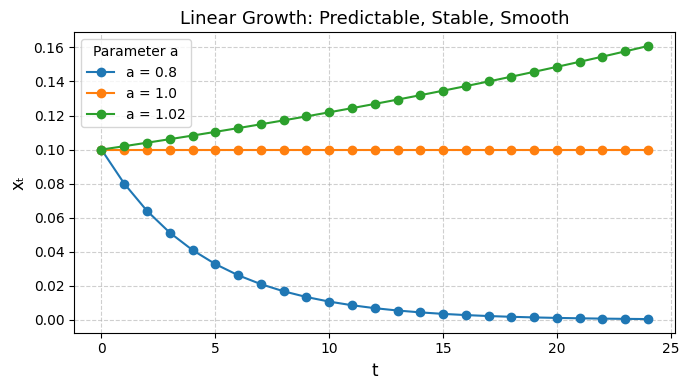

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def linear_growth(a, xStart=0.1, steps=25):
    xNext_all = [xStart]
    for t in range(steps - 1):
        currentX = xNext_all[-1]
        xNext_all.append(a * currentX)
    return np.array(xNext_all)

# Parameters for comparison
as_ = [0.8, 1.0, 1.02]

# ---- Plot ---- #
plt.figure(figsize=(7,4))

for a in as_:
    xs = linear_growth(a)
    plt.plot(xs, marker='o', label=f"a = {a}")

plt.title("Linear Growth: Predictable, Stable, Smooth", fontsize=13)
plt.xlabel("t", fontsize=12)
plt.ylabel("xₜ", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title="Parameter a")
plt.tight_layout()
plt.show()

In [2]:
from ipywidgets import interact, FloatSlider
from IPython.display import clear_output


def update_plot(a, x0=0.1, steps=25):
    clear_output(wait=True)
    xs = linear_growth(a, xStart=x0, steps=steps)

    # Regime label (conceptual hook)
    if np.isclose(a, 1.0, atol=1e-6):
        regime = "Neutral: constant level"
    elif a < 1.0:
        regime = "Stable: decay toward 0"
    else:
        regime = "Unstable: exponential growth"

    plt.figure(figsize=(9, 5))
    plt.plot(xs, marker='o', linewidth=2, label=rf"$a = {a:.2f}$")
    plt.axhline(y=x0, linestyle='--', alpha=0.4, label=rf"Start ($x_0={x0}$)")

    plt.title(rf"Linear Growth: $x_{{t+1}} = a x_t$  |  {regime}", fontsize=14)
    plt.xlabel("Time step (t)", fontsize=12)
    plt.ylabel(r"Value ($x_t$)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    y_min, y_max = xs.min(), xs.max()
    padding = 0.1*(y_max - y_min) if y_max != y_min else 0.05
    plt.ylim(max(0, y_min - padding), y_max + padding)

    plt.legend()
    plt.show()

interact(
    update_plot,
    a=FloatSlider(value=0.95, min=0.1, max=1.3, step=0.01, description='a'),
);


interactive(children=(FloatSlider(value=0.95, description='a', max=1.3, min=0.1, step=0.01), FloatSlider(value…

In [3]:
import pandas as pd
import statsmodels.api as sm

# --- Generate linear data --- #
a = 1.02
x = linear_growth(a, xStart=0.2, steps=50)

# Build regression data
# x_t is all but last point
# x_{t+1} is all but first point
df_reg = pd.DataFrame({
    "x_t": x[:-1],
    "x_next": x[1:]
})

# --- Run OLS regression: x_next ~ x_t --- #
X = sm.add_constant(df_reg["x_t"])
y = df_reg["x_next"]

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 x_next   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.757e+31
Date:                Wed, 09 Sep 2026   Prob (F-statistic):               0.00
Time:                        23:50:07   Log-Likelihood:                 1714.2
No. Observations:                  49   AIC:                            -3424.
Df Residuals:                      47   BIC:                            -3421.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.117e-17   8.45e-17     -0.132      0.8

In [4]:
df_reg

,x_t,x_next
0,0.200000,0.204000
1,0.204000,0.208080
2,0.208080,0.212242
3,0.212242,0.216486
4,0.216486,0.220816
5,0.220816,0.225232
6,0.225232,0.229737
7,0.229737,0.234332
8,0.234332,0.239019
9,0.239019,0.243799
